In [1]:
import os

os.listdir()

['.config',
 'customer_churn_dataset-testing-master.csv',
 'customer_churn_dataset-training-master.csv',
 'sample_data']

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load training dataset
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")

# Load testing dataset
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [4]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [6]:
print(train_df.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [8]:
train_df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [9]:
train_df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [10]:
train_df["Churn"].value_counts()

,count
Churn,
1.0,249999
0.0,190833


In [11]:
train_df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
1.0,56.71072
0.0,43.28928


In [12]:
print("Rows and Columns:", train_df.shape)

Rows and Columns: (440833, 12)


In [13]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


In [14]:
train_df = train_df.drop_duplicates()

In [15]:
train_df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [16]:
train_df.fillna(train_df.median(numeric_only=True), inplace=True)

In [17]:
for col in train_df.select_dtypes(include='object').columns:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)

In [18]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [19]:
categorical_cols = X_train.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

In [21]:
print(y_train.unique())

[1. 0.]


In [22]:
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

In [23]:
print(X_train.head())
print(y_train[:5])
print(X_train.shape)
print(X_test.shape)

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0       0    39.0             14.0            5.0   
1         3.0  65.0       0    49.0              1.0           10.0   
2         4.0  55.0       0    14.0              4.0            6.0   
3         5.0  58.0       1    38.0             21.0            7.0   
4         6.0  23.0       1    32.0             20.0            5.0   

   Payment Delay  Subscription Type  Contract Length  Total Spend  \
0           18.0                  2                0        932.0   
1            8.0                  0                1        557.0   
2           18.0                  0                2        185.0   
3            7.0                  2                1        396.0   
4            8.0                  0                1        617.0   

   Last Interaction  
0              17.0  
1               6.0  
2               3.0  
3              29.0  
4              20.0  
[1 1 1 1 1]
(440833, 11)
(

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
print(X_train_scaled[:5])

[[-1.74008988e+00 -7.53327082e-01 -1.14591125e+00  4.48759994e-01
  -2.10510974e-01  4.54550107e-01  6.09621432e-01  1.21154265e+00
  -1.11466088e+00  1.24742792e+00  2.93052343e-01]
 [-1.74008216e+00  2.05964832e+00 -1.14591125e+00  1.02827904e+00
  -1.72456451e+00  2.08310265e+00 -6.01319089e-01 -1.24555938e+00
   1.69415975e-03 -3.09865147e-01 -9.86584599e-01]
 [-1.74007444e+00  1.25594106e+00 -1.14591125e+00 -1.00003762e+00
  -1.37516754e+00  7.80260615e-01  6.09621432e-01 -1.24555938e+00
   1.11804920e+00 -1.85469987e+00 -1.33557649e+00]
 [-1.74006672e+00  1.49705324e+00  8.72667928e-01  3.90808089e-01
   6.04748619e-01  1.10597112e+00 -7.22413141e-01  1.21154265e+00
   1.69415975e-03 -9.78462971e-01  1.68901992e+00]
 [-1.74005900e+00 -1.31592216e+00  8.72667928e-01  4.30966620e-02
   4.88282963e-01  4.54550107e-01 -6.01319089e-01 -1.24555938e+00
   1.69415975e-03 -6.06982566e-02  6.42044236e-01]]


In [28]:
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (440833, 11)
Testing Data Shape: (64374, 11)


In [29]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [31]:
baseline = LogisticRegression(max_iter=1000, random_state=42)

In [32]:
baseline.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
y_pred = baseline.predict(X_test_scaled)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.47368502811694163


In [35]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.47368502811694163
Recall: 1.0
F1 Score: 0.6428578957909494


In [36]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[    0 33881]
 [    0 30493]]


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



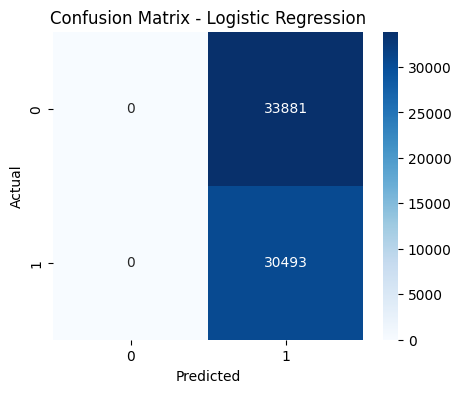

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

In [41]:
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [42]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [43]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [44]:
print("Best CV Accuracy:", grid.best_score_)

Best CV Accuracy: 0.9510062947497611


In [45]:
best_model = grid.best_estimator_

In [46]:
y_pred_best = best_model.predict(X_test_scaled)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

Accuracy: 0.47368502811694163
Precision: 0.47368502811694163
Recall: 1.0
F1 Score: 0.6428578957909494


In [48]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     33881
           1       0.47      1.00      0.64     30493

    accuracy                           0.47     64374
   macro avg       0.24      0.50      0.32     64374
weighted avg       0.22      0.47      0.30     64374



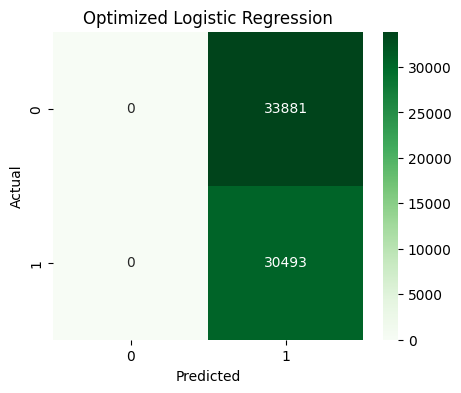

In [49]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Logistic Regression")
plt.show()

In [50]:
import joblib

In [51]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [52]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [53]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [54]:
target_encoder = LabelEncoder()

In [55]:
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']

In [56]:
import os

print(os.listdir())

['.config', 'label_encoders.pkl', 'customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv', 'scaler.pkl', 'model.pkl', 'target_encoder.pkl', 'sample_data']


In [57]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
files.download("target_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
import joblib

# Load model and preprocessing objects
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoders = joblib.load("label_encoders.pkl")

# Load target encoder only if you saved it
# target_encoder = joblib.load("target_encoder.pkl")

In [60]:
new_customer = {
    "Age": 35,
    "Gender": "Male",
    "Tenure": 12,
    "Usage Frequency": 15,
    "Support Calls": 2,
    "Payment Delay": 5,
    "Subscription Type": "Standard",
    "Contract Length": "Annual",
    "Total Spend": 550
}

In [61]:
new_df = pd.DataFrame([new_customer])

In [62]:
for col in label_encoders:
    new_df[col] = label_encoders[col].transform(new_df[col])

In [63]:
new_scaled = scaler.transform(new_df)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- CustomerID
- Last Interaction


In [64]:
print(X_train.columns.tolist())

['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']


In [65]:
new_customer = {
    "CustomerID": 100001,
    "Age": 35,
    "Gender": "Male",
    "Tenure": 12,
    "Usage Frequency": 15,
    "Support Calls": 2,
    "Payment Delay": 5,
    "Subscription Type": "Standard",
    "Contract Length": "Annual",
    "Total Spend": 550,
    "Last Interaction": 10
}

In [66]:
new_df = pd.DataFrame([new_customer])

# Encode categorical columns
for col in label_encoders:
    if col in new_df.columns:
        new_df[col] = label_encoders[col].transform(new_df[col])

# Arrange columns exactly like training data
new_df = new_df[X_train.columns]

# Scale
new_scaled = scaler.transform(new_df)

# Predict
prediction = model.predict(new_scaled)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Customer will Churn")
else:
    print("Customer will NOT Churn")

Prediction: [1]
Customer will Churn
